# Bank Credit Card Churn Prediction
## Modeling

I build machine learning models to predict customer churn, evaluate their performance, and identify the most important 
factors driving churn. I use results from EDA, use feature selection, handle class imbalance with SMOTE and compare multiple models 
to find the best one.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

from imblearn.over_sampling import SMOTE

import shap

### PART 1: Data Preprocessing

In [33]:
df = pd.read_csv('BankChurners.csv')
df = df.iloc[:,:-2]
df['Churn'] =(df['Attrition_Flag']=='Attrited Customer').astype(int)
df = df.drop(['CLIENTNUM','Attrition_Flag'], axis=1)
# Drop Avg_Open_To_Buy - highly correlated with Credit_Limit
df = df.drop('Avg_Open_To_Buy', axis=1)

In [34]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
le =LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(f"shape after encoding: {df.shape}")
df.head()

shape after encoding: (10127, 19)


,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,1.335,1144,42,1.625,0.061,0
1,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,1.541,1291,33,3.714,0.105,0
2,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,2.594,1887,20,2.333,0.000,0
3,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,1.405,1171,20,2.333,0.760,0
4,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,2.175,816,28,2.500,0.000,0


### PART 2: Feature Selection

I select the most relevant features based on EDA.

In [35]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used for modeling:")
for col in X.columns:
    print(f"  -{col}")

Features shape: (10127, 18)
Target shape: (10127,)

Features used for modeling:
  -Customer_Age
  -Gender
  -Dependent_count
  -Education_Level
  -Marital_Status
  -Income_Category
  -Card_Category
  -Months_on_book
  -Total_Relationship_Count
  -Months_Inactive_12_mon
  -Contacts_Count_12_mon
  -Credit_Limit
  -Total_Revolving_Bal
  -Total_Amt_Chng_Q4_Q1
  -Total_Trans_Amt
  -Total_Trans_Ct
  -Total_Ct_Chng_Q4_Q1
  -Avg_Utilization_Ratio


### PART 3: Train Test Split

I split the data into 80% training and 20% test sets. I do it before SMOTE to prevent data leakage.

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"training set:")
print(y_train.value_counts())
print(f" test set:")
print(y_test.value_counts())

Training set: 8101 rows
Test set: 2026 rows
training set:
Churn
0    6799
1    1302
Name: count, dtype: int64
 test set:
Churn
0    1701
1     325
Name: count, dtype: int64


### PART 4: Handling Class Imbalance with SMOTE

16% churn rate means significant class imbalance.
I use SMOTE which creates synthetic samples of churned customers to balance the dataset.
it is applied only on training data to prevent data leakage.
Applying SMOTE before splitting would cause fake data to leak into test set and it woould make evaluation results unrealistic.

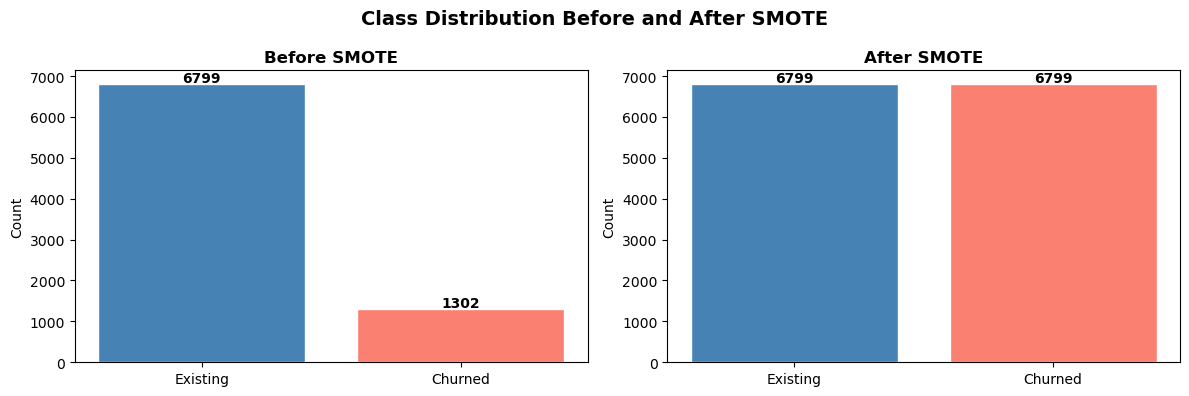

In [37]:
smote = SMOTE(random_state =42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)

fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(['Existing','Churned'], [sum(y_train==0),sum(y_train==1)], color=['steelblue','salmon'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
for i,v in enumerate([sum(y_train==0), sum(y_train==1)]):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

axes[1].bar(['Existing','Churned'], [sum(y_train_res==0), sum(y_train_res==1)], color=['steelblue','salmon'], edgecolor='white')
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
for i,v in enumerate([sum(y_train_res==0),sum(y_train_res==1)]):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before and After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/smote_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### PART 5: Model Building

I build four models:
1. Logistic Regression — simple baseline model
2. Decision Tree — interpretable tree based model  
3. Random Forest — ensemble model
4. XGBoost — advanced gradient boosting model

Each model is evaluated using: Accuracy, Precision, Recall, F1-Score, Confusion Matrix

In [38]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy  = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1= f1_score(y_test,y_pred)

    print(f"{model_name}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.1f}%)")
    print(f"Recall: {recall:.4f} ({recall*100:.1f}%)")
    print(f"F1-Score: {f1:.4f} ({f1*100:.1f}%)")
    print(f"Classification Report:")
    print(classification_report(y_test,y_pred, target_names=['Existing', 'Churned']))
    return {'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1}
    